In [8]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 62.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.3 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [9]:
import random
import statistics

from typing import Dict, Optional
import matplotlib.pyplot as plt

## Default

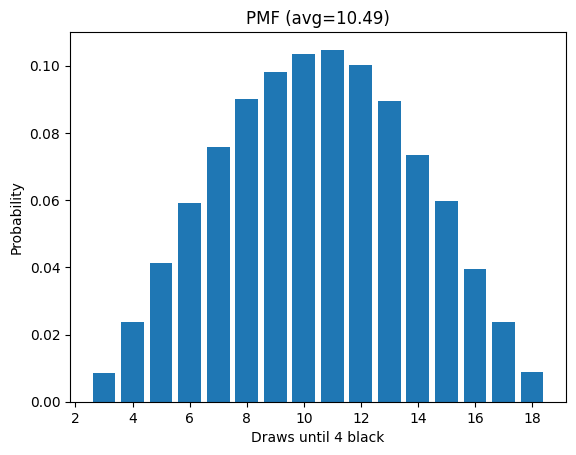

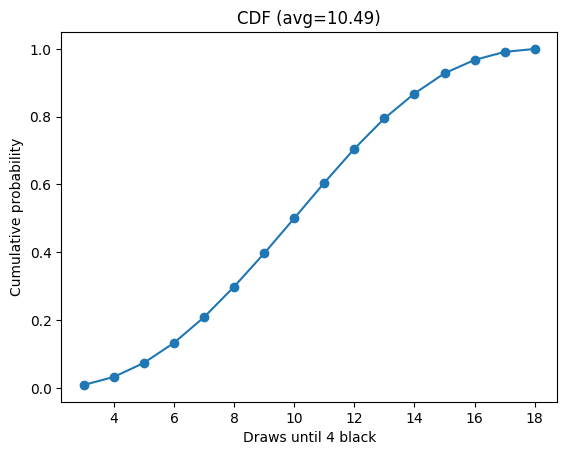

10.48752

In [25]:
# Add cumulative probability plot to the simulation

import random
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Parameters
num_black = 5
num_non_black = 15
target_black = 3
num_trials = 100000

def run_trial(num_black, num_non_black, target_black):
    balls = [1]*num_black + [0]*num_non_black
    random.shuffle(balls)
    
    black_count = 0
    draws = 0
    
    for ball in balls:
        draws += 1
        if ball == 1:
            black_count += 1
        if black_count == target_black:
            return draws

results = [run_trial(num_black, num_non_black, target_black) for _ in range(num_trials)]

avg = sum(results) / len(results)

counter = Counter(results)
xs = sorted(counter.keys())
probs = np.array([counter[x] / num_trials for x in xs])

# cumulative probability
cum_probs = np.cumsum(probs)

# Plot PMF
plt.figure()
plt.bar(xs, probs)
plt.xlabel("Draws until 4 black")
plt.ylabel("Probability")
plt.title(f"PMF (avg={avg:.2f})")
plt.show()

# Plot CDF
plt.figure()
plt.plot(xs, cum_probs, marker='o')
plt.xlabel("Draws until 4 black")
plt.ylabel("Cumulative probability")
plt.title(f"CDF (avg={avg:.2f})")
plt.show()

avg

max_draws= 1, expected_score=1.0000
max_draws= 2, expected_score=2.0000
max_draws= 3, expected_score=2.9594
max_draws= 4, expected_score=3.8342
max_draws= 5, expected_score=4.6006
max_draws= 6, expected_score=5.2247
max_draws= 7, expected_score=5.7293
max_draws= 8, expected_score=6.0653
max_draws= 9, expected_score=6.2743
max_draws=10, expected_score=6.3666
max_draws=11, expected_score=6.3374
max_draws=12, expected_score=6.2600
max_draws=13, expected_score=6.0662
max_draws=14, expected_score=5.9017
max_draws=15, expected_score=5.7463
max_draws=16, expected_score=5.6190
max_draws=17, expected_score=5.5297
max_draws=18, expected_score=5.4890
max_draws=19, expected_score=5.4863
max_draws=20, expected_score=5.4970


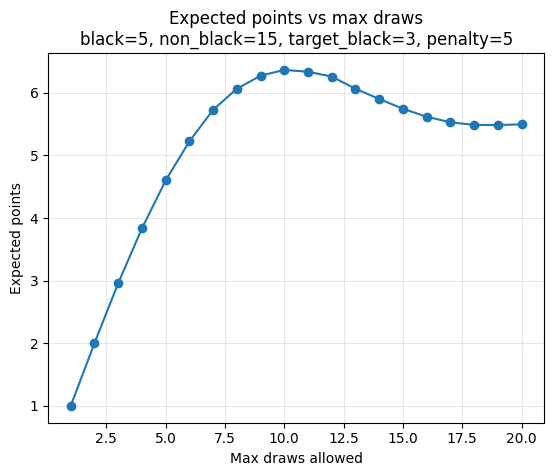

In [32]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Parameters
num_black = 5
num_non_black = 3 * num_black
target_black = 3
penalty_if_target_hit = 5
num_trials = 100000

total_balls = num_black + num_non_black

def run_trial(num_black, num_non_black, target_black, max_draws, penalty_if_target_hit):
    balls = [1] * num_black + [0] * num_non_black
    random.shuffle(balls)

    black_count = 0
    draws_made = 0
    hit_target = False

    for ball in balls[:max_draws]:
        draws_made += 1
        if ball == 1:
            black_count += 1
        if black_count == target_black:
            hit_target = True
            break

    score = draws_made
    if hit_target:
        score -= penalty_if_target_hit

    return score

max_draw_values = list(range(1, total_balls + 1))
expected_scores = []

for max_draws in max_draw_values:
    scores = [
        run_trial(
            num_black=num_black,
            num_non_black=num_non_black,
            target_black=target_black,
            max_draws=max_draws,
            penalty_if_target_hit=penalty_if_target_hit
        )
        for _ in range(num_trials)
    ]

    expected_score = sum(scores) / len(scores)
    expected_scores.append(expected_score)
    print(f"max_draws={max_draws:2d}, expected_score={expected_score:.4f}")

plt.figure()
plt.plot(max_draw_values, expected_scores, marker='o')
plt.xlabel("Max draws allowed")
plt.ylabel("Expected points")
plt.title(
    f"Expected points vs max draws\n"
    f"black={num_black}, non_black={num_non_black}, target_black={target_black}, penalty={penalty_if_target_hit}"
)
plt.grid(True, alpha=0.3)
plt.show()

# OLD

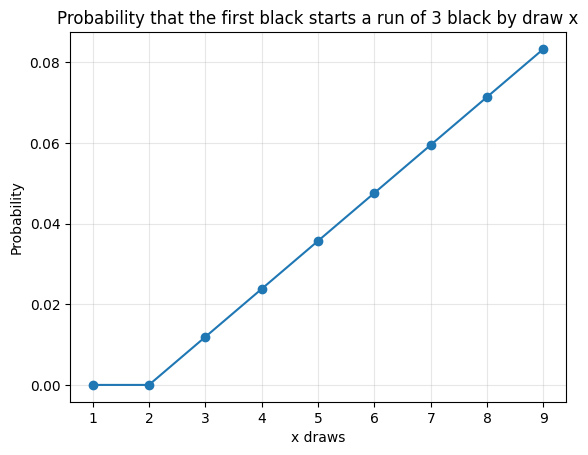

In [14]:
import math
import matplotlib.pyplot as plt

num_black = 3
num_non_black = 6
total = num_black + num_non_black
target_run = 3

def prob_k(k, num_black=6, num_non_black=12, target_run=3):
    total = num_black + num_non_black
    
    if k < 0:
        return 0.0
    if k > num_non_black:
        return 0.0
    if num_black < target_run:
        return 0.0
    if k + target_run > total:
        return 0.0
    
    p = 1.0
    
    # first k draws are non-black
    for i in range(k):
        p *= (num_non_black - i) / (total - i)
    
    # next target_run draws are black
    for j in range(target_run):
        p *= (num_black - j) / (total - k - j)
    
    return p

def prob_by_x(x, num_black=6, num_non_black=12, target_run=3):
    max_k = min(num_non_black, x - target_run)
    if max_k < 0:
        return 0.0
    return sum(prob_k(k, num_black, num_non_black, target_run) for k in range(max_k + 1))

xs = list(range(1, total + 1))
probs = [prob_by_x(x, num_black, num_non_black, target_run) for x in xs]

#for x, p in zip(xs, probs):
#    print(f"x={x:2d}, probability={p:.6f}")

plt.figure()
plt.plot(xs, probs, marker='o')
plt.xlabel("x draws")
plt.ylabel("Probability")
plt.title("Probability that the first black starts a run of 3 black by draw x")
plt.grid(True, alpha=0.3)
plt.show()

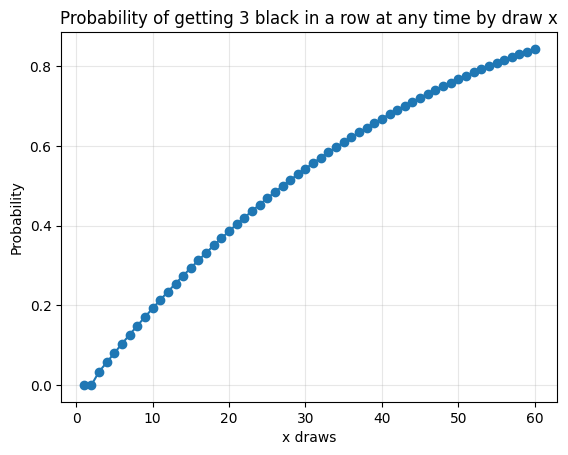

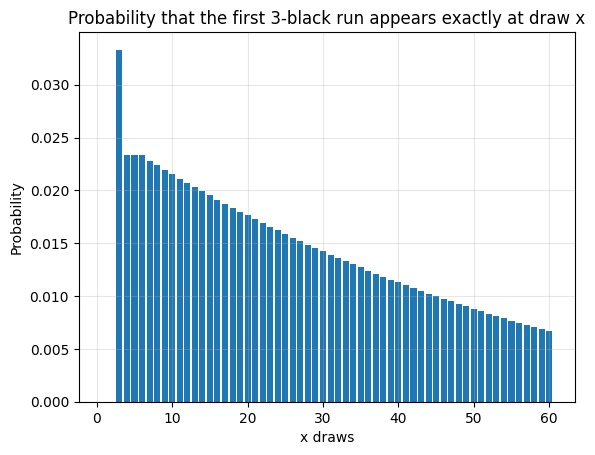

In [24]:
import matplotlib.pyplot as plt
from functools import lru_cache

num_black = 20
num_non_black = 40
total = num_black + num_non_black
target_run = 3

def prob_run_by_x(x, num_black, num_non_black, target_run):
    @lru_cache(None)
    def f(draws_left, b, n, streak):
        if streak >= target_run:
            return 1.0
        if draws_left == 0:
            return 0.0
        
        total_left = b + n
        p = 0.0
        
        if b > 0:
            p += (b / total_left) * f(draws_left - 1, b - 1, n, streak + 1)
        
        if n > 0:
            p += (n / total_left) * f(draws_left - 1, b, n - 1, 0)
        
        return p
    
    return f(x, num_black, num_non_black, 0)

xs = list(range(1, total + 1))
cdf = [prob_run_by_x(x, num_black, num_non_black, target_run) for x in xs]

pmf = []
prev = 0.0
for p in cdf:
    pmf.append(p - prev)
    prev = p

plt.figure()
plt.plot(xs, cdf, marker='o')
plt.xlabel("x draws")
plt.ylabel("Probability")
plt.title("Probability of getting 3 black in a row at any time by draw x")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.bar(xs, pmf)
plt.xlabel("x draws")
plt.ylabel("Probability")
plt.title("Probability that the first 3-black run appears exactly at draw x")
plt.grid(True, alpha=0.3)
plt.show()